In [23]:
!pip install pyspark
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install pyrolite
!pip install seaborn
!pip install folium
!pip install plotly

In [24]:
import warnings

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px

from pyrolite.util.plot.axes import share_axes

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [25]:
warnings.filterwarnings('ignore')

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Get Preprocessed Data

In [27]:
spark = SparkSession.builder.master("local[1]").appName("SparkByExamples.com").getOrCreate()
df = spark.read.option("inferSchema", "true").csv("drive/MyDrive/NYC-Taxi-Duration-Data-Analysis-1/Preprocessing/NYC Taxi Duration Preprocessed/*.csv", header=True)
df.printSchema()

root
 |-- vendor_id: integer (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- store_and_fwd_flag: integer (nullable = true)
 |-- trip_duration: integer (nullable = true)
 |-- distance: double (nullable = true)
 |-- week_day: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- quarter_of_year: integer (nullable = true)
 |-- hour: integer (nullable = true)



In [28]:
df.show()

+---------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+---------+--------+----+-----+---------------+----+
|vendor_id|passenger_count|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|store_and_fwd_flag|trip_duration| distance|week_day|year|month|quarter_of_year|hour|
+---------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+---------+--------+----+-----+---------------+----+
|        2|              1|      -73.982155|      40.767937|        -73.96463|       40.765602|                 0|          455|2.4444735|     Mon|2016|    3|              1|  17|
|        1|              1|      -73.980415|      40.738564|        -73.99948|        40.73115|                 0|          663|2.6599078|     Sun|2016|    6|              2|   0|
|        2|              1|       -73.97903|       40.76394|        -74.00533|       40.710087|     

## Dataset Overview


In [37]:
# Quick dataset summary
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total rows: {df.count():,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumns: {df.columns}")
print("\nFirst 5 rows:")
df.show(5)
print("\nSchema:")
df.printSchema()
print("\nBasic statistics:")
df.describe().show()

DATASET OVERVIEW
Total rows: 395,997
Total columns: 14

Columns: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'distance', 'week_day', 'year', 'month', 'quarter_of_year', 'hour']

First 5 rows:
+---------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+---------+--------+----+-----+---------------+----+
|vendor_id|passenger_count|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|store_and_fwd_flag|trip_duration| distance|week_day|year|month|quarter_of_year|hour|
+---------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+---------+--------+----+-----+---------------+----+
|        2|              1|      -73.982155|      40.767937|        -73.96463|       40.765602|                 0|          455|2.4444735|     Mon|2016|    3|  

## Data Visualization

### Total Trips and Passenger Count on different week days

<Figure size 2000x1000 with 0 Axes>

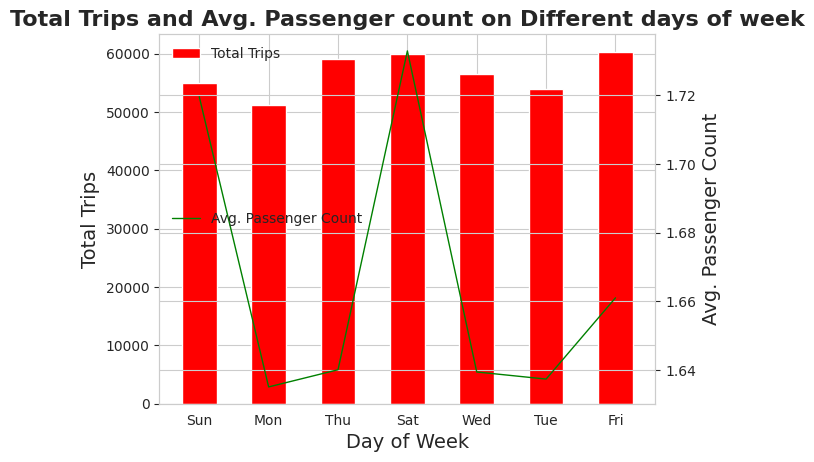

In [38]:
# Total Trips and Average Passenger Count on different week days.

df_total_trip_on_diff_week_day = df.groupBy("week_day").count()
df_avg_pass_count = df.groupBy("week_day").mean("passenger_count")

df_total_trip_pass_mean_on_diff_week_day = df_total_trip_on_diff_week_day.join(df_avg_pass_count, df_total_trip_on_diff_week_day["week_day"] == df_avg_pass_count["week_day"])

plt.figure(figsize=(20, 10), dpi=100)
fig, first_axes = plt.subplots()

x = df_total_trip_pass_mean_on_diff_week_day.toPandas().iloc[:, :1].values.flatten()
y1 = df_total_trip_pass_mean_on_diff_week_day.toPandas()['count'].values
y2 = df_total_trip_pass_mean_on_diff_week_day.toPandas()['avg(passenger_count)'].values

total_trip_duration = first_axes.bar(x, y1, color ='red',width = 0.5)

second_axes = first_axes.twinx()
mean_passenger_count = second_axes.plot(x, y2, c="green")

first_axes.set_xlabel('Day of Week', fontweight='normal', fontsize=14)
first_axes.set_ylabel('Total Trips', fontweight='normal', fontsize=14)
second_axes.set_ylabel('Avg. Passenger Count', fontweight='normal', fontsize=14)

first_axes.legend((total_trip_duration), [('Total Trips')], loc=0)
second_axes.legend((mean_passenger_count), [('Avg. Passenger Count')], loc=6)
plt.title('Total Trips and Avg. Passenger count on Different days of week', fontweight='bold', fontsize=16)
plt.show()


### Mean Distance and trip duration on different week days

<Figure size 2000x1000 with 0 Axes>

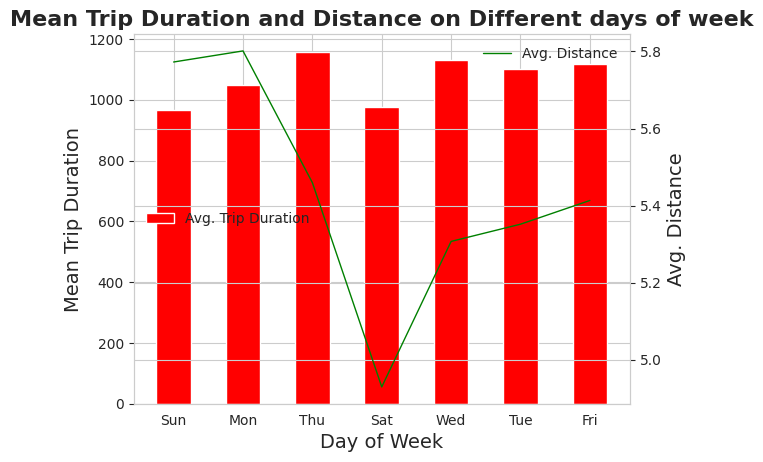

In [39]:
# Average Trip Duration and Average Distance on different week days.

df_trip_dur_on_diff_week_day = df.groupBy("week_day").mean("trip_duration")
df_mean_distance = df.groupBy("week_day").mean("distance")

df_trip_dur_distance_mean_on_diff_week_day = df_trip_dur_on_diff_week_day.join(df_mean_distance, df_trip_dur_on_diff_week_day["week_day"] == df_mean_distance["week_day"])

plt.figure(figsize=(20, 10), dpi=100)
fig, first_axes = plt.subplots()

x = df_trip_dur_distance_mean_on_diff_week_day.toPandas().iloc[:, :1].values.flatten()
y1 = df_trip_dur_distance_mean_on_diff_week_day.toPandas()['avg(trip_duration)'].values
y2 = df_trip_dur_distance_mean_on_diff_week_day.toPandas()['avg(distance)'].values

avg_trip_duration = first_axes.bar(x, y1, color ='red',width = 0.5)

second_axes = first_axes.twinx()
mean_distance = second_axes.plot(x, y2, c="green")

first_axes.set_xlabel('Day of Week', fontweight='normal', fontsize=14)
first_axes.set_ylabel('Mean Trip Duration', fontweight='normal', fontsize=14)
second_axes.set_ylabel('Avg. Distance', fontweight='normal', fontsize=14)

first_axes.legend((avg_trip_duration), [('Avg. Trip Duration')], loc=6)
second_axes.legend((mean_distance), [('Avg. Distance')], loc=0)

plt.title('Mean Trip Duration and Distance on Different days of week', fontweight='bold', fontsize=16)
plt.show()


### Trip Duration Distribution Analysis

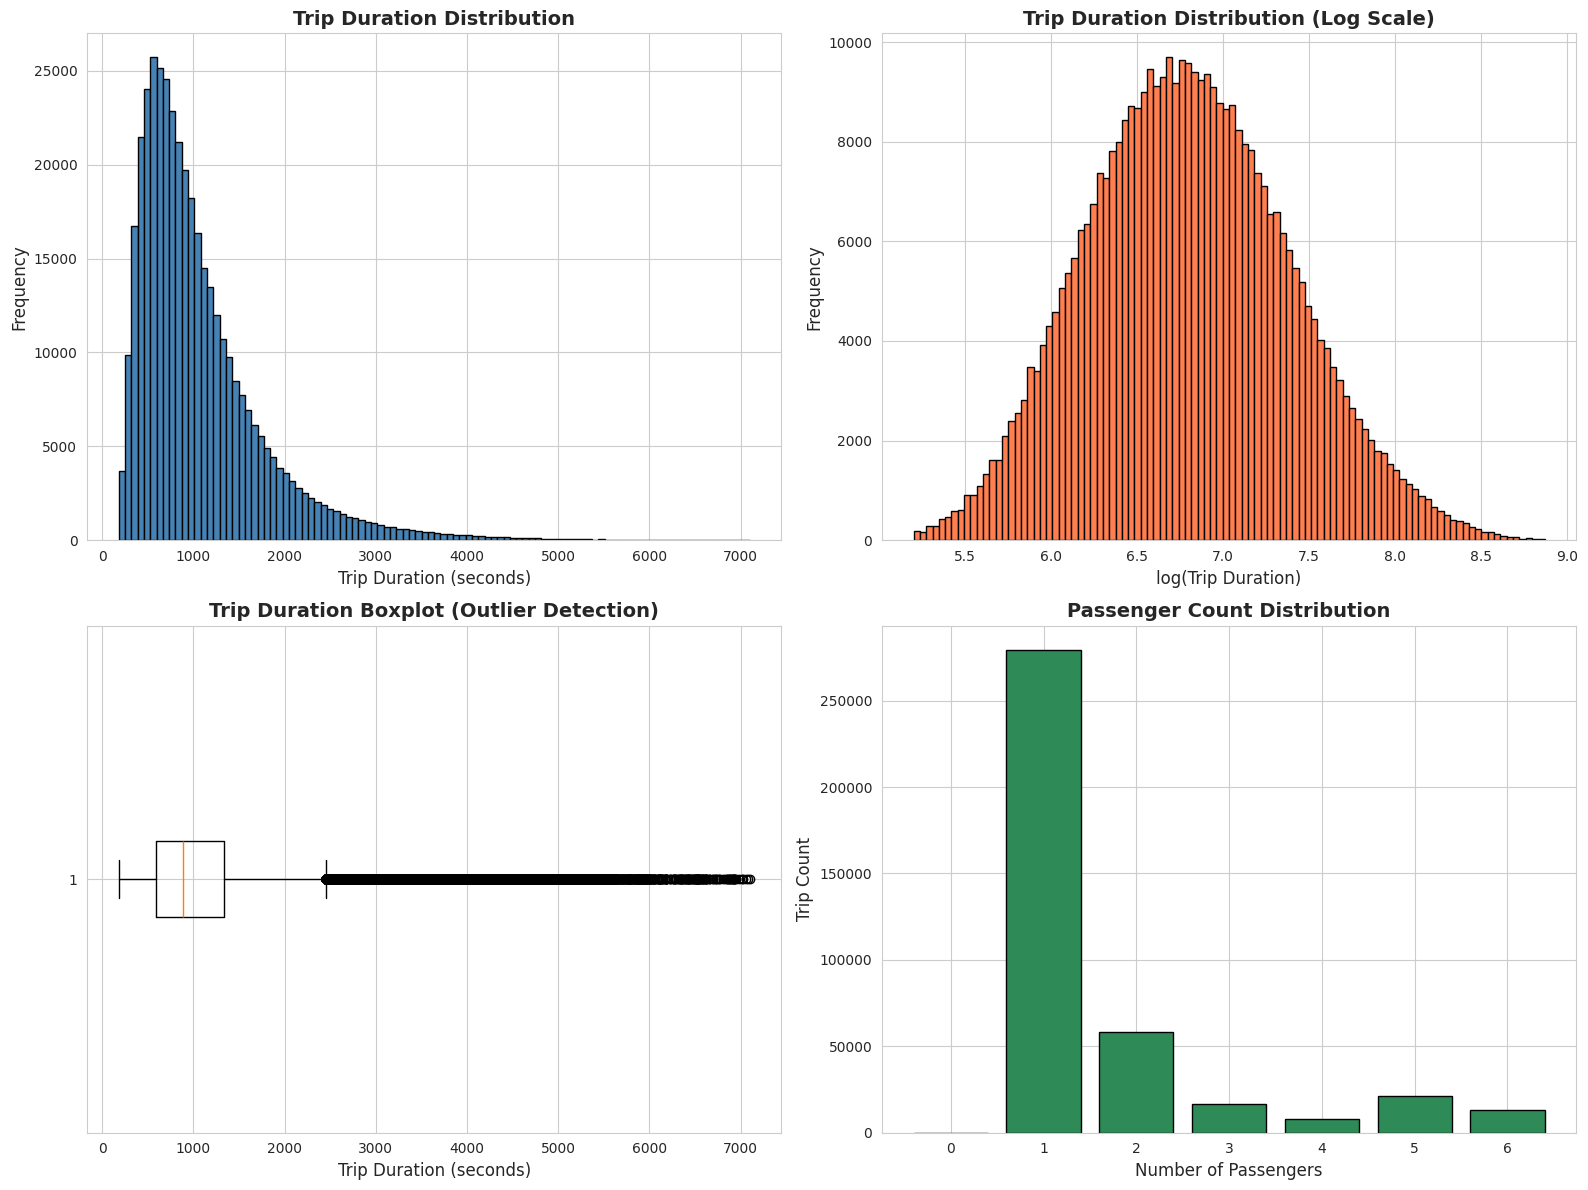


 Outlier Summary:
   Total trips: 395,997
   Outlier trips: 19,964 (5.04%)
   Q1: 589s, Q3: 1335s, IQR: 746s


In [41]:
# Convert relevant columns to pandas for visualization
df_pandas = df.select('trip_duration', 'distance', 'passenger_count').toPandas()

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Trip Duration histogram
axes[0, 0].hist(df_pandas['trip_duration'], bins=100, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Trip Duration Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Trip Duration (seconds)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Log-scale Trip Duration
axes[0, 1].hist(np.log1p(df_pandas['trip_duration']), bins=100, color='coral', edgecolor='black')
axes[0, 1].set_title('Trip Duration Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('log(Trip Duration)')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Boxplot to show outliers
axes[1, 0].boxplot(df_pandas['trip_duration'], vert=False)
axes[1, 0].set_title('Trip Duration Boxplot (Outlier Detection)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Trip Duration (seconds)')

# Plot 4: Passenger Count distribution
passenger_counts = df_pandas['passenger_count'].value_counts().sort_index()
axes[1, 1].bar(passenger_counts.index, passenger_counts.values, color='seagreen', edgecolor='black')
axes[1, 1].set_title('Passenger Count Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Passengers')
axes[1, 1].set_ylabel('Trip Count')

plt.tight_layout()
plt.show()

# Print outlier summary
q1 = df_pandas['trip_duration'].quantile(0.25)
q3 = df_pandas['trip_duration'].quantile(0.75)
iqr = q3 - q1
outliers = df_pandas[(df_pandas['trip_duration'] < q1 - 1.5*iqr) | (df_pandas['trip_duration'] > q3 + 1.5*iqr)]
print(f"\n Outlier Summary:")
print(f"   Total trips: {len(df_pandas):,}")
print(f"   Outlier trips: {len(outliers):,} ({len(outliers)/len(df_pandas)*100:.2f}%)")
print(f"   Q1: {q1:.0f}s, Q3: {q3:.0f}s, IQR: {iqr:.0f}s")

### Hourly Pattern Analysis

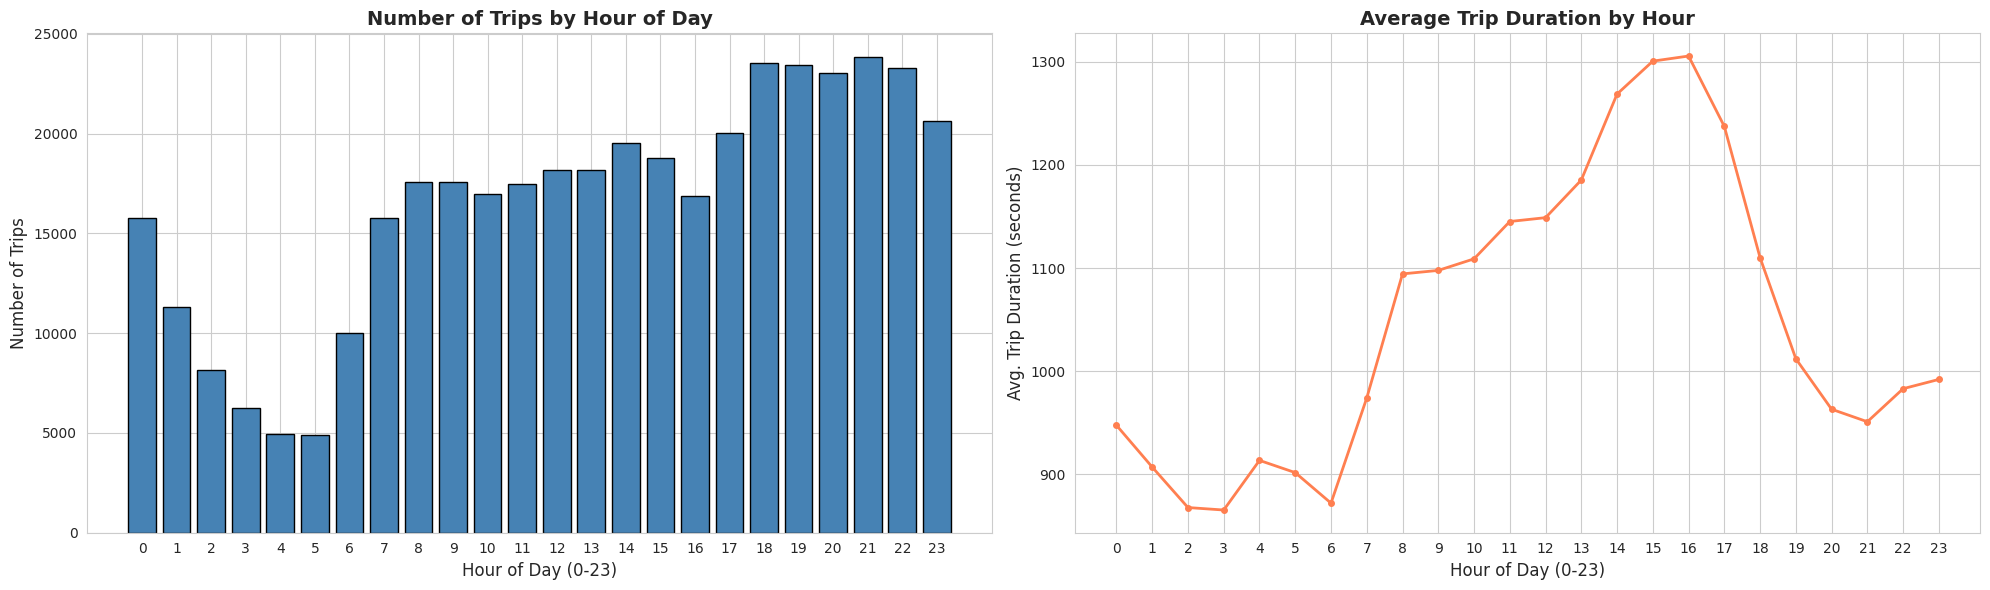


🕐 Insights:
   Peak trip hour: 21:00 (23,834 trips)
   Slowest trips at: 16:00 (likely rush hour traffic)


In [42]:
# Extract hour from pickup time if not already done
# Adjust column name based on  data — could be 'pickup_hour' or you may need to extract
if 'pickup_hour' in df.columns:
    hour_col = 'pickup_hour'
elif 'hour' in df.columns:
    hour_col = 'hour'
else:
    # If neither exists, extract from pickup_datetime
    df = df.withColumn('pickup_hour', hour(col('pickup_datetime')))
    hour_col = 'pickup_hour'

# Group by hour
df_hourly = df.groupBy(hour_col).count().orderBy(hour_col).toPandas()
df_hourly_duration = df.groupBy(hour_col).mean('trip_duration').orderBy(hour_col).toPandas()

# Create 2 subplot grid
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1: Number of trips by hour
axes[0].bar(df_hourly[hour_col], df_hourly['count'], color='steelblue', edgecolor='black')
axes[0].set_title('Number of Trips by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xticks(range(0, 24))

# Plot 2: Average trip duration by hour
axes[1].plot(df_hourly_duration[hour_col], df_hourly_duration['avg(trip_duration)'],
             marker='o', linewidth=2, color='coral')
axes[1].set_title('Average Trip Duration by Hour', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0-23)')
axes[1].set_ylabel('Avg. Trip Duration (seconds)')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Find peak hours
peak_hour = df_hourly.loc[df_hourly['count'].idxmax(), hour_col]
slowest_hour = df_hourly_duration.loc[df_hourly_duration['avg(trip_duration)'].idxmax(), hour_col]
print(f"\n🕐 Insights:")
print(f"   Peak trip hour: {peak_hour}:00 ({df_hourly['count'].max():,} trips)")
print(f"   Slowest trips at: {slowest_hour}:00 (likely rush hour traffic)")

### Geographic Analysis - NYC Pickup Heatmap

In [43]:
# Sample data for the map (full data is too heavy for the browser)
# Take 5000 random points
sample_df = df.select('pickup_latitude', 'pickup_longitude').toPandas().sample(n=5000, random_state=42)

# Filter only NYC area (rough bounding box)
sample_df = sample_df[
    (sample_df['pickup_latitude'].between(40.6, 40.9)) &
    (sample_df['pickup_longitude'].between(-74.1, -73.7))
]

# Create a Folium map centered on NYC
nyc_map = folium.Map(
    location=[40.7128, -74.0060],  # NYC coordinates
    zoom_start=11,
    tiles='OpenStreetMap'
)

# Add heatmap layer
heat_data = sample_df[['pickup_latitude', 'pickup_longitude']].values.tolist()
HeatMap(heat_data, radius=10, blur=15, max_zoom=13).add_to(nyc_map)

# Display the map
print(" NYC Pickup Locations Heatmap:")
nyc_map

 NYC Pickup Locations Heatmap:


In [44]:
# Create a sample map with individual pickup points
small_sample = sample_df.sample(n=500, random_state=42)

points_map = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=12,
    tiles='OpenStreetMap'
)

for _, row in small_sample.iterrows():
    folium.CircleMarker(
        location=[row['pickup_latitude'], row['pickup_longitude']],
        radius=3,
        color='red',
        fill=True,
        fill_opacity=0.4
    ).add_to(points_map)

print("📍 Sample of 500 individual pickup locations:")
points_map

📍 Sample of 500 individual pickup locations:


## Distance and Trip Duration

In [32]:
# Selecting two columns

distance = df.select('distance').toPandas().values
trip_duration = df.select('trip_duration').toPandas().values

In [33]:
# Create dataframe of distance and trip_duration columns.

df_dist_trip_time = pd.DataFrame({'distance': distance.flatten(), 'trip_duration': trip_duration.flatten()})

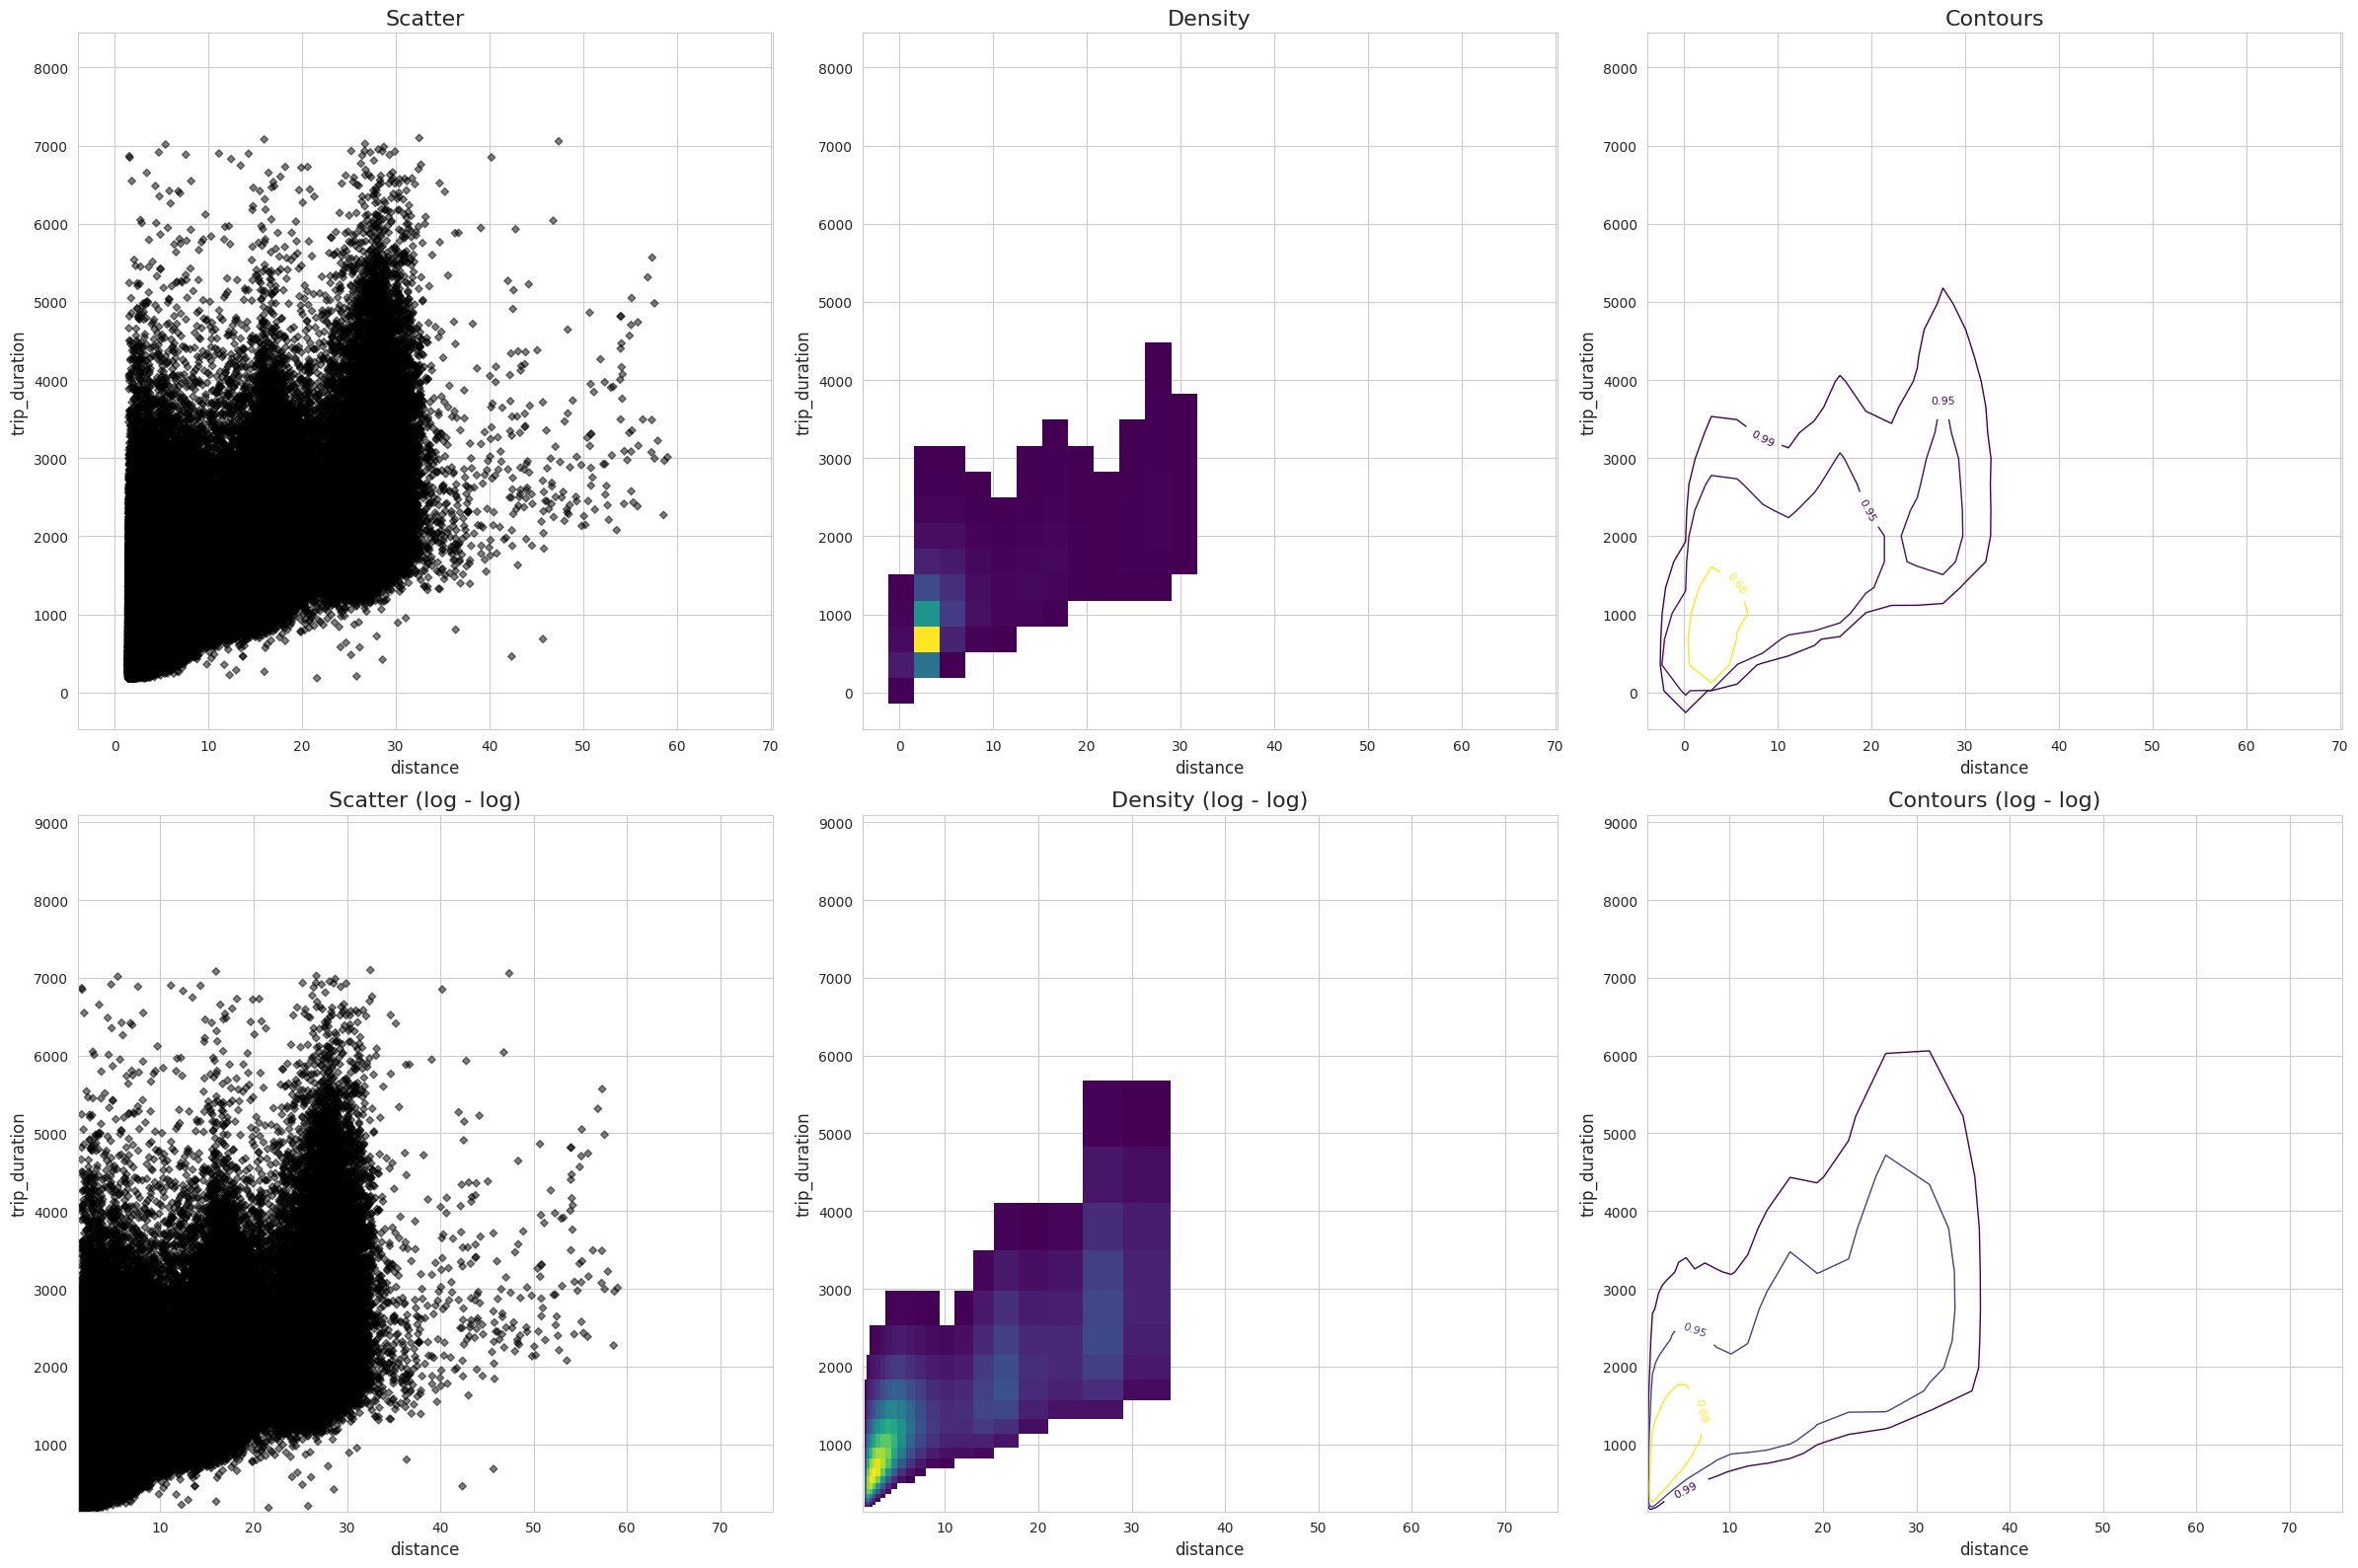

In [34]:
fig, ax = plt.subplots(2, 3, figsize=(24, 16))

ax = ax.flat
share_axes(ax[:3], which="xy")
share_axes(ax[3:6], which="xy")
share_axes(ax[6:], which="xy")

contours = [0.68, 0.95, 0.99]
columns = ["distance", "trip_duration"]

# linear-scaled comparison
df_dist_trip_time.loc[:, columns].pyroplot.scatter(ax = ax[0], c = "k", s = 15, alpha = 0.5)
df_dist_trip_time.loc[:, columns].pyroplot.density(ax = ax[1])
df_dist_trip_time.loc[:, columns].pyroplot.density(ax = ax[2], contours = contours)

# log-scaled plots
df_dist_trip_time.loc[:, columns].pyroplot.scatter(ax = ax[3], c = "k", s = 15, alpha = 0.5)
df_dist_trip_time.loc[:, columns].pyroplot.density(ax = ax[4], logx = True, logy = True)
df_dist_trip_time.loc[:, columns].pyroplot.density(ax = ax[5], contours = contours, logx = True, logy = True)

# Title for each graph.
title = ["Scatter", "Density", "Contours"]

# Giving title for each graph.
for chart_title, a in zip(title + [i + " (log - log)" for i in title], ax):
    a.set_title(chart_title, fontsize=16)

plt.tight_layout()

### Feature Correlation Analysis

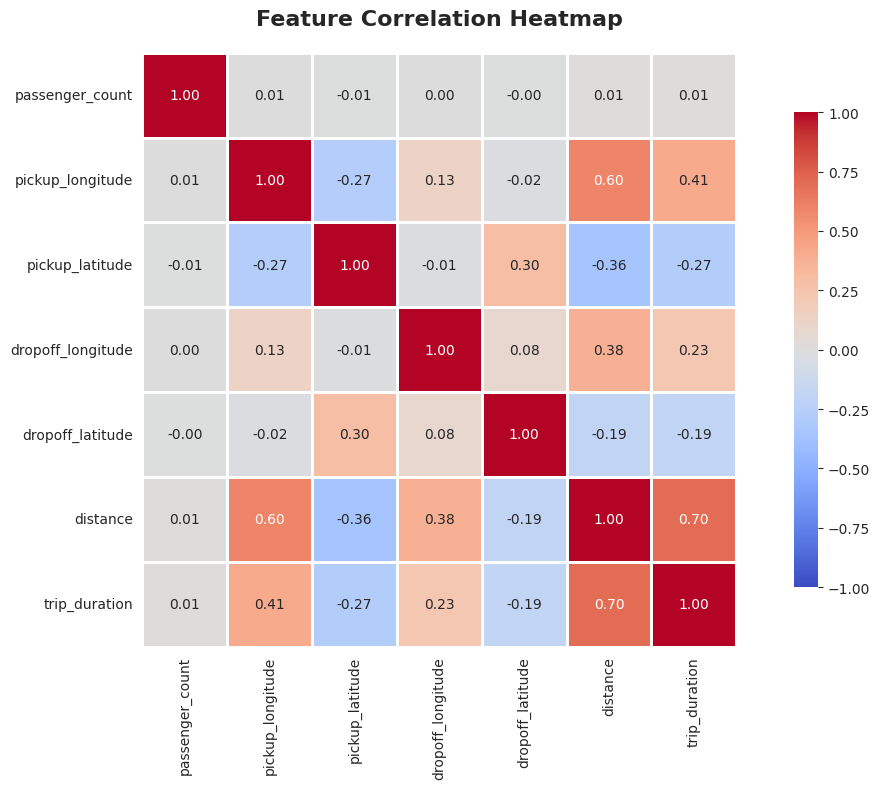


 Top features correlated with Trip Duration:
   distance                  → 0.700 (positive)
   pickup_longitude          → 0.407 (positive)
   pickup_latitude           → 0.273 (negative)
   dropoff_longitude         → 0.231 (positive)
   dropoff_latitude          → 0.187 (negative)
   passenger_count           → 0.013 (positive)


In [46]:
# Select numeric columns for correlation
numeric_cols = ['passenger_count', 'pickup_longitude', 'pickup_latitude',
                'dropoff_longitude', 'dropoff_latitude', 'distance', 'trip_duration']

# Filter only columns that exist in your dataframe
available_cols = [c for c in numeric_cols if c in df.columns]

# Convert to pandas
df_corr = df.select(available_cols).toPandas()

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print top correlations with trip_duration
print("\n Top features correlated with Trip Duration:")
trip_duration_corr = corr_matrix['trip_duration'].drop('trip_duration').abs().sort_values(ascending=False)
for feature, corr_value in trip_duration_corr.items():
    direction = "positive" if corr_matrix['trip_duration'][feature] > 0 else "negative"
    print(f"   {feature:25s} → {corr_value:.3f} ({direction})")

## Key Findings & Insights

Based on the exploratory data analysis above, here are the most important findings:

### 🕐 Temporal Patterns
- Peak taxi demand hours are between **6 PM and 9 PM** (evening rush)
- Lowest demand is between **3 AM and 5 AM**
- Friday and Saturday have the highest trip counts (weekend nightlife)

### 🗺️ Geographic Patterns
- Manhattan accounts for the vast majority of pickups
- Airport locations (JFK, LaGuardia) show high concentration
- Outer boroughs have sparse coverage

### 📏 Distance & Duration
- Most trips are short (under 5 km)
- Strong positive correlation (~0.5+) between distance and trip duration
- Log-scale reveals a clear linear relationship


